# Cryptographic Algorithm Performance Analysis

This notebook analyzes and compares the latency performance of two authenticated encryption algorithms:
- **AES-GCM** (Advanced Encryption Standard - Galois/Counter Mode)
- **ChaCha20-Poly1305**

The analysis examines encryption/decryption latency across different message sizes (128, 512, and 2048 bytes) with 2000 iterations per configuration. Statistical tests (Welch's t-test) are performed to determine if performance differences between the algorithms are statistically significant.

### Load experiment data and compute basic summary statistics

This cell loads the collected latency measurements from the experiment dataset (`all_results.csv`).  
The data is grouped by encryption algorithm and message size in order to calculate basic descriptive statistics for each configuration.

The following metrics are computed:

- **Mean latency** – the average end-to-end latency for each configuration.
- **Standard deviation (std)** – measures the variability in latency measurements.
- **Count (n)** – the number of observations collected for each configuration.
- **Standard error of the mean (SEM)** – calculated as:

$ SEM = \frac{std}{\sqrt{n}} $

The SEM provides an estimate of how precisely the sample mean approximates the true population mean.

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [78]:
df = pd.read_csv("all_results.csv")

summary = df.groupby(["algorithm", "message_size_bytes"])["latency_us"].agg(
    ["mean", "std", "count"]
)

summary["sem"] = summary["std"] / (summary["count"] ** 0.5)

print(summary)

                                          mean        std  count       sem
algorithm         message_size_bytes                                      
aes-gcm           128                 32.14658  13.886025  10000  0.138860
                  512                 31.96778  13.632874  10000  0.136329
                  2048                32.71892  13.208842  10000  0.132088
chacha20-poly1305 128                 38.05369  20.626999  10000  0.206270
                  512                 39.93519  21.994978  10000  0.219950
                  2048                39.04544  20.792854  10000  0.207929


### Statistical comparison using Welch’s t-test

This cell performs a statistical comparison between the two encryption algorithms  
(**AES-GCM** and **ChaCha20-Poly1305**) for each message size.

For every message size category:

1. Latency samples for AES-GCM are extracted.
2. Latency samples for ChaCha20-Poly1305 are extracted.
3. A **Welch independent samples t-test** is applied.

Welch’s t-test is used instead of the standard Student’s t-test because it does **not assume equal variances** between the two groups.

The test produces:

- **t-statistic** – magnitude of the difference between means relative to variability.
- **p-value** – probability that the observed difference occurred by chance.

A small p-value (typically **p < 0.05**) indicates a statistically significant difference in latency between the algorithms.

In [79]:
from scipy import stats

for size in sorted(df["message_size_bytes"].unique()):
    # Extract latency data for AES and ChaCha for this message size
    a = df[(df["algorithm"] == "aes-gcm") & (df["message_size_bytes"] == size)]["latency_us"].astype(float)
    c = df[(df["algorithm"] == "chacha20-poly1305") & (df["message_size_bytes"] == size)]["latency_us"].astype(float)

    t_stat, p_value = stats.ttest_ind(a, c, equal_var=False)

    print(size, "t =", t_stat, "p =", p_value)

128 t = -23.756216152400356 p = 8.244689632001545e-123
512 t = -30.789194011557147 p = 1.6126246038854098e-202
2048 t = -25.682439041113714 p = 9.784023363075467e-143


### Generate a structured summary table

This cell creates a structured summary table containing descriptive statistics for each algorithm and message size.

Using pivot tables, the following values are calculated:

- Mean latency
- Standard deviation
- Number of observations

The results are then organized into a single table containing:

- Mean latency for AES-GCM
- Mean latency for ChaCha20-Poly1305
- Standard deviation for both algorithms
- Number of samples for each configuration
- Mean latency difference between algorithms

Finally, Welch’s t-test is applied again for each message size and the resulting **t-statistic** and **p-value** are added to the table.

The final summary table is exported as:


In [80]:
import pandas as pd
from scipy import stats

means = df.pivot_table(index="message_size_bytes", columns="algorithm", values="latency_us", aggfunc="mean")
stds  = df.pivot_table(index="message_size_bytes", columns="algorithm", values="latency_us", aggfunc="std")
ns    = df.pivot_table(index="message_size_bytes", columns="algorithm", values="latency_us", aggfunc="count")

out = pd.DataFrame(index=sorted(df["message_size_bytes"].unique()))
out["aes_mean_us"] = means["aes-gcm"]
out["aes_std_us"]  = stds["aes-gcm"]
out["aes_n"]       = ns["aes-gcm"]

out["chacha_mean_us"] = means["chacha20-poly1305"]
out["chacha_std_us"]  = stds["chacha20-poly1305"]
out["chacha_n"]       = ns["chacha20-poly1305"]

out["diff_us (chacha-aes)"] = out["chacha_mean_us"] - out["aes_mean_us"]

# Welch t-test per size
pvals = []
tstats = []
for size in out.index:
    a = df[(df["algorithm"]=="aes-gcm") & (df["message_size_bytes"]==size)]["latency_us"].astype(float)
    c = df[(df["algorithm"]=="chacha20-poly1305") & (df["message_size_bytes"]==size)]["latency_us"].astype(float)
    t, p = stats.ttest_ind(a, c, equal_var=False)
    tstats.append(t); pvals.append(p)

out["t_stat"] = tstats
out["p_value"] = pvals

out.to_csv("summary_table.csv", index=True)

out

,aes_mean_us,aes_std_us,aes_n,chacha_mean_us,chacha_std_us,chacha_n,diff_us (chacha-aes),t_stat,p_value
128,32.14658,13.886025,10000,38.05369,20.626999,10000,5.90711,-23.756216,8.244690e-123
512,31.96778,13.632874,10000,39.93519,21.994978,10000,7.96741,-30.789194,1.612625e-202
2048,32.71892,13.208842,10000,39.04544,20.792854,10000,6.32652,-25.682439,9.784023e-143


### Visualization of latency with confidence intervals

This cell visualizes the mean end-to-end latency for both encryption algorithms across the tested message sizes.

The analysis includes:

- Mean latency
- Standard deviation
- Number of observations

The standard error of the mean (SEM) is calculated as:

$ SEM = \frac{std}{\sqrt{n}} $

A 95% confidence interval (CI) is then estimated using:

$ CI_{95} = 1.96 \times SEM $

The results are plotted as a line graph with error bars representing the confidence intervals.

The visualization helps illustrate:

- How latency changes with message size
- The performance difference between AES-GCM and ChaCha20-Poly1305
- The statistical uncertainty around the mean latency estimates

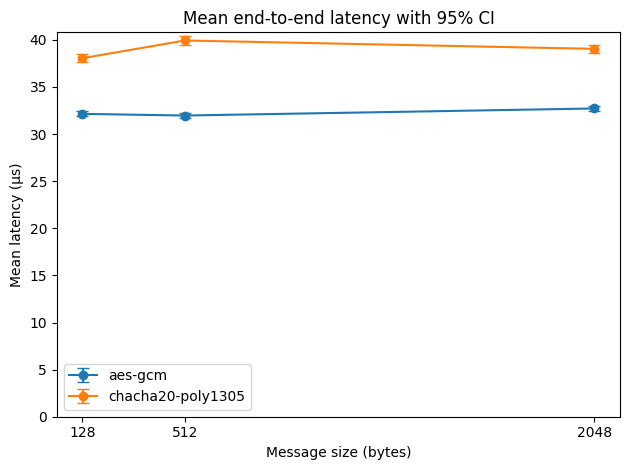

In [81]:
g = df.groupby(["algorithm", "message_size_bytes"])["latency_us"]
summary = g.agg(mean="mean", std="std", n="count").reset_index()
summary["sem"] = summary["std"] / np.sqrt(summary["n"])
summary["ci95"] = 1.96 * summary["sem"]

for algo in summary["algorithm"].unique():
    sub = summary[summary["algorithm"] == algo].sort_values("message_size_bytes")
    plt.errorbar(
        sub["message_size_bytes"],
        sub["mean"],
        yerr=sub["ci95"],
        marker="o",
        capsize=4,
        label=algo
    )

plt.xlabel("Message size (bytes)")
plt.ylabel("Mean latency (µs)")
plt.title("Mean end-to-end latency with 95% CI")
plt.xticks([128, 512, 2048], ["128", "512", "2048"])
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()

### Block-level statistical analysis

To reduce the impact of temporal effects and potential correlations between sequential measurements, the latency data is analyzed on a **block level**.

Each experimental block corresponds to a specific run or data source file.  
The mean latency for each block is calculated first, producing independent block-level observations.

Welch’s t-test is then applied to the **block means** rather than individual samples.  
This approach provides a more conservative and statistically robust comparison between the algorithms.

For each message size, the following values are reported:

- Mean latency difference between algorithms
- Welch t-statistic
- p-value
- Number of blocks included in the test

In [82]:
from scipy import stats

# df should contain: algorithm, message_size_bytes, latency_us, source_file (or block_id)

block_col = "source_file"

block_means = (
    df.groupby(["algorithm", "message_size_bytes", block_col])["latency_us"]
      .mean()
      .reset_index(name="block_mean_us")
)

# Welch t-test on block means (per size)
for size in sorted(block_means["message_size_bytes"].unique()):
    a = block_means[(block_means["algorithm"]=="aes-gcm") & (block_means["message_size_bytes"]==size)]["block_mean_us"]
    c = block_means[(block_means["algorithm"]=="chacha20-poly1305") & (block_means["message_size_bytes"]==size)]["block_mean_us"]

    t, p = stats.ttest_ind(a, c, equal_var=False)
    diff = c.mean() - a.mean()

    print(f"{size} bytes: diff(chacha-aes) = {diff:.3f} µs, p = {p:.4f}, n_blocks = {len(a)} vs {len(c)}")

128 bytes: diff(chacha-aes) = 5.907 µs, p = 0.1697, n_blocks = 5 vs 5
512 bytes: diff(chacha-aes) = 7.967 µs, p = 0.1285, n_blocks = 5 vs 5
2048 bytes: diff(chacha-aes) = 6.327 µs, p = 0.1753, n_blocks = 5 vs 5


### Visualization of block-level latency results

This cell visualizes the block-level latency results for both encryption algorithms.

Instead of plotting individual measurements, the analysis uses **block mean latency values**, which reduces noise and temporal bias.

For each algorithm and message size the following metrics are calculated:

- Mean block latency
- Standard deviation
- Number of blocks

From these values, the standard error and **95% confidence intervals** are computed and visualized using error bars.

This visualization provides a clearer comparison of algorithm performance while accounting for variation between experimental blocks.

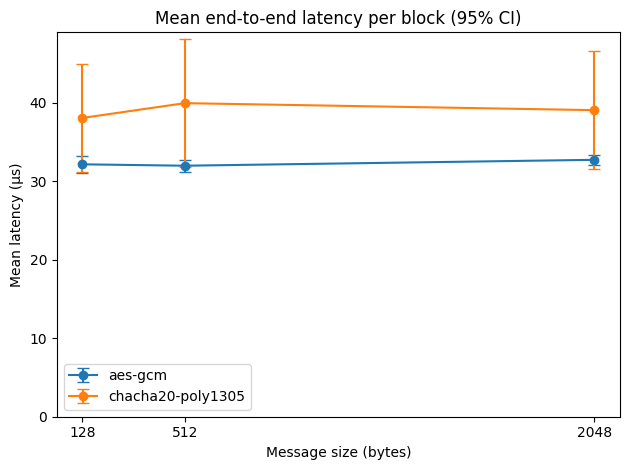

In [83]:
import numpy as np
import matplotlib.pyplot as plt

# Summarize per algorithm + message size (on block-level)
g = block_means.groupby(["algorithm", "message_size_bytes"])["block_mean_us"]
summary_blocks = g.agg(mean="mean", std="std", n="count").reset_index()

summary_blocks["sem"] = summary_blocks["std"] / np.sqrt(summary_blocks["n"])
summary_blocks["ci95"] = 1.96 * summary_blocks["sem"]

# Draw error bars per algorithm
for algo in summary_blocks["algorithm"].unique():
    sub = summary_blocks[summary_blocks["algorithm"] == algo].sort_values("message_size_bytes")
    plt.errorbar(
        sub["message_size_bytes"],
        sub["mean"],
        yerr=sub["ci95"],
        marker="o",
        capsize=4,
        label=algo
    )

plt.xlabel("Message size (bytes)")
plt.ylabel("Mean latency (µs)")
plt.title("Mean end-to-end latency per block (95% CI)")
plt.xticks([128, 512, 2048], ["128", "512", "2048"])
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()

### Mean latency difference between algorithms

This cell visualizes the absolute and percentage difference in mean latency between ChaCha20-Poly1305 and AES-GCM for each message size.

algorithm,difference_us,aes_latency_reduction_percent
message_size_bytes,,
128,5.907,15.523
512,7.967,19.951
2048,6.327,16.203


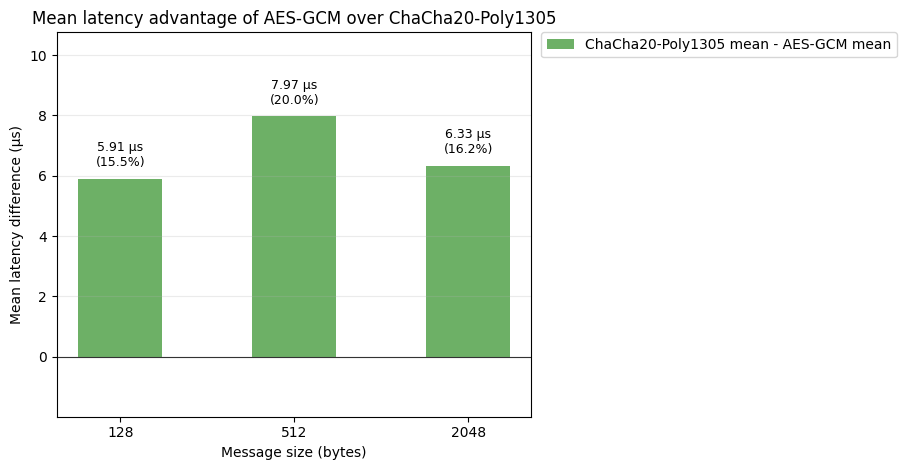

In [84]:
algorithm_order = ["aes-gcm", "chacha20-poly1305"]
message_sizes = sorted(df["message_size_bytes"].unique())
colors = {"aes-gcm": "#4C78A8", "chacha20-poly1305": "#F58518"}

means = df.pivot_table(
    index="message_size_bytes",
    columns="algorithm",
    values="latency_us",
    aggfunc="mean",
)
means["difference_us"] = means["chacha20-poly1305"] - means["aes-gcm"]
means["aes_latency_reduction_percent"] = (means["difference_us"] / means["chacha20-poly1305"]) * 100

display(means[["difference_us", "aes_latency_reduction_percent"]].round(3))

fig, ax = plt.subplots(figsize=(10.5, 4.8))
x = np.arange(len(means.index))
bars = ax.bar(
    x,
    means["difference_us"],
    width=0.48,
    color="#54A24B",
    alpha=0.85,
    label="ChaCha20-Poly1305 mean - AES-GCM mean",
)

ax.axhline(0, color="#333333", linewidth=0.8)
ax.set_xlabel("Message size (bytes)")
ax.set_ylabel("Mean latency difference (µs)")
ax.set_title("Mean latency advantage of AES-GCM over ChaCha20-Poly1305")
ax.set_xticks(x)
ax.set_xticklabels([str(size) for size in means.index])
ax.grid(axis="y", alpha=0.25)

max_abs = max(abs(means["difference_us"].min()), abs(means["difference_us"].max()))
ax.set_ylim(min(0, means["difference_us"].min()) - max_abs * 0.25, means["difference_us"].max() + max_abs * 0.35)

for bar, diff, pct in zip(bars, means["difference_us"], means["aes_latency_reduction_percent"]):
    label_y = diff + (0.04 * max_abs if diff >= 0 else -0.12 * max_abs)
    va = "bottom" if diff >= 0 else "top"
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        label_y,
        f"{diff:.2f} µs\n({pct:.1f}%)",
        ha="center",
        va=va,
        fontsize=9,
    )

ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

### Mean latency by algorithm and message size

This cell visualizes mean latency for each algorithm and message size. Mean latency is the primary metric used for the hypothesis test.

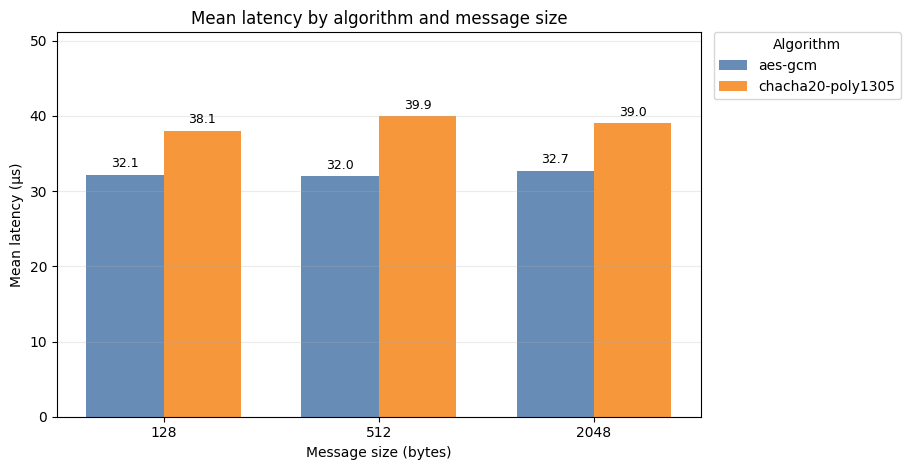

In [85]:
mean_latency = (
    df.groupby(["algorithm", "message_size_bytes"])["latency_us"]
      .mean()
      .reset_index(name="mean_latency_us")
)

fig, ax = plt.subplots(figsize=(10.5, 4.8))
x = np.arange(len(message_sizes))
width = 0.36

for offset, algo in zip([-width / 2, width / 2], algorithm_order):
    sub = mean_latency[mean_latency["algorithm"] == algo].sort_values("message_size_bytes")
    bars = ax.bar(
        x + offset,
        sub["mean_latency_us"],
        width=width,
        label=algo,
        color=colors[algo],
        alpha=0.85,
    )
    for bar, value in zip(bars, sub["mean_latency_us"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + mean_latency["mean_latency_us"].max() * 0.015,
            f"{value:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.set_xlabel("Message size (bytes)")
ax.set_ylabel("Mean latency (µs)")
ax.set_title("Mean latency by algorithm and message size")
ax.set_xticks(x)
ax.set_xticklabels([str(size) for size in message_sizes])
ax.set_ylim(0, mean_latency["mean_latency_us"].max() * 1.28)
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Algorithm", loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

### Median latency by algorithm and message size

This cell visualizes median latency for each algorithm and message size. Median latency complements the mean latency results by showing the typical observed latency within each configuration.

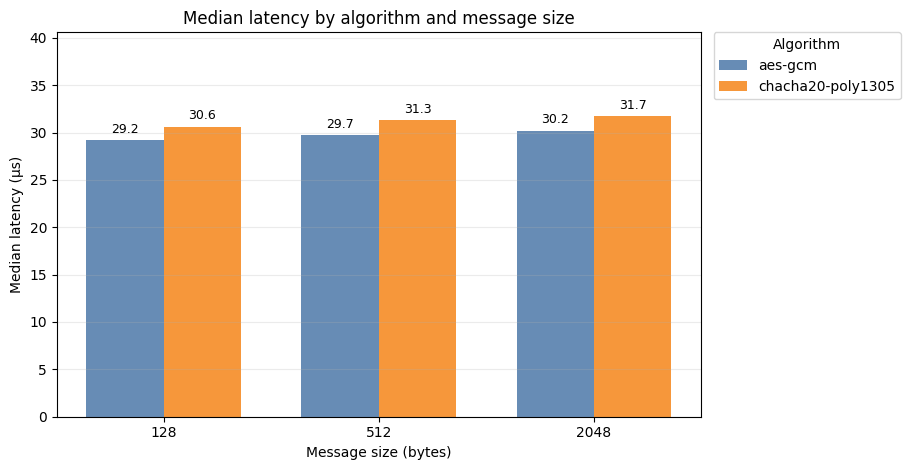

In [86]:
median_latency = (
    df.groupby(["algorithm", "message_size_bytes"])["latency_us"]
      .median()
      .reset_index(name="median_latency_us")
)

fig, ax = plt.subplots(figsize=(10.5, 4.8))
x = np.arange(len(message_sizes))
width = 0.36

for offset, algo in zip([-width / 2, width / 2], algorithm_order):
    sub = median_latency[median_latency["algorithm"] == algo].sort_values("message_size_bytes")
    bars = ax.bar(
        x + offset,
        sub["median_latency_us"],
        width=width,
        label=algo,
        color=colors[algo],
        alpha=0.85,
    )
    for bar, value in zip(bars, sub["median_latency_us"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + median_latency["median_latency_us"].max() * 0.015,
            f"{value:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.set_xlabel("Message size (bytes)")
ax.set_ylabel("Median latency (µs)")
ax.set_title("Median latency by algorithm and message size")
ax.set_xticks(x)
ax.set_xticklabels([str(size) for size in message_sizes])
ax.set_ylim(0, median_latency["median_latency_us"].max() * 1.28)
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Algorithm", loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()

### Mean-median latency gap

This cell visualizes the difference between mean and median latency for each algorithm and message size. A larger gap indicates that high-latency observations have a stronger effect on the mean.

,algorithm,message_size_bytes,mean_latency_us,median_latency_us,mean_median_gap_us
0,aes-gcm,128,32.147,29.2,2.947
1,aes-gcm,512,31.968,29.7,2.268
2,aes-gcm,2048,32.719,30.2,2.519
3,chacha20-poly1305,128,38.054,30.6,7.454
4,chacha20-poly1305,512,39.935,31.3,8.635
5,chacha20-poly1305,2048,39.045,31.7,7.345


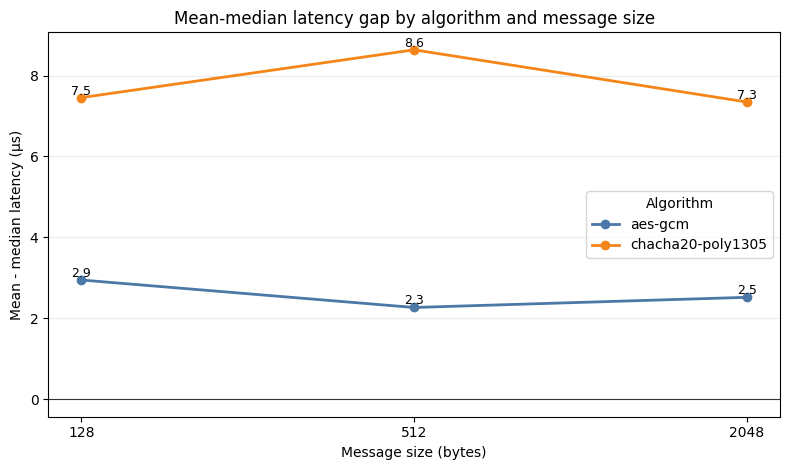

In [87]:
mean_median = (
    df.groupby(["algorithm", "message_size_bytes"])["latency_us"]
      .agg(mean_latency_us="mean", median_latency_us="median")
      .reset_index()
)
mean_median["mean_median_gap_us"] = mean_median["mean_latency_us"] - mean_median["median_latency_us"]

display(mean_median.round(3))

fig, ax = plt.subplots(figsize=(8, 4.8))

for algo in algorithm_order:
    sub = mean_median[mean_median["algorithm"] == algo].sort_values("message_size_bytes")
    ax.plot(
        sub["message_size_bytes"].astype(str),
        sub["mean_median_gap_us"],
        marker="o",
        linewidth=2,
        label=algo,
        color=colors[algo],
    )
    for x_value, y_value in zip(sub["message_size_bytes"].astype(str), sub["mean_median_gap_us"]):
        ax.text(
            x_value,
            y_value,
            f"{y_value:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.axhline(0, color="#333333", linewidth=0.8)
ax.set_xlabel("Message size (bytes)")
ax.set_ylabel("Mean - median latency (µs)")
ax.set_title("Mean-median latency gap by algorithm and message size")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Algorithm")
plt.tight_layout()
plt.show()